In [1]:
"""
Complete RTL SHAP Plot Testing - All Plot Types
================================================
This demonstrates how users will use the shap_rtl package.
All plots are called directly with NO wrappers, NO manual RTL handling.
Works in both Jupyter notebooks and Python scripts.
"""

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ============================================================
# SETUP PATH FOR PACKAGE (Only needed for development)
# ============================================================
# Try to find shap_rtl package automatically
def find_shap_rtl():
    """Find shap_rtl package in common locations."""
    possible_paths = [
        # Current directory
        os.path.join(os.getcwd(), "shap_rtl"),
        # Parent directory
        os.path.join(os.path.dirname(os.getcwd()), "shap_rtl"),
        # src directory
        os.path.join(os.getcwd(), "src", "shap_rtl"),
        # Parent src directory
        os.path.join(os.path.dirname(os.getcwd()), "src", "shap_rtl"),
        # Current working directory
        os.getcwd(),
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            parent_dir = os.path.dirname(path)
            if parent_dir not in sys.path:
                sys.path.insert(0, parent_dir)
                print(f"[INFO] Added to path: {parent_dir}")
                return True
    return False

# Try to find the package
if not find_shap_rtl():
    print("[WARNING] Could not find shap_rtl package. Make sure it's installed or in your path.")
    print("[INFO] If developing locally, set the path manually:")
    print("  sys.path.insert(0, '/path/to/shap_rtl/parent/directory')")


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Added to path: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package


In [2]:
# ============================================================
# USER IMPORTS - DIRECT FROM PACKAGE
# ============================================================
try:
    from shap_rtl import RTLSHAPExplainer
    from shap_rtl.plots import (
        waterfall,      # Single sample - shows feature contributions
        bar,            # Feature importance bar chart
        beeswarm,       # Beeswarm plot (like summary but with dots)
        summary_plot,   # Summary plot with feature importance
        heatmap,        # Heatmap across multiple samples
        scatter,        # Scatter plot for feature relationships
        decision_plot,  # Decision plot showing prediction path
        dependence_plot # Dependence plot for feature interactions
    )
    print("[INFO] shap_rtl imported successfully!")
except ImportError as e:
    print(f"[ERROR] Could not import shap_rtl: {e}")
    print("[INFO] Please install shap_rtl or add it to your Python path.")
    sys.exit(1)


[INFO] RTL font initialized: NotoSansArabic-Regular.ttf
[INFO] shap_rtl imported successfully!


RTL SHAP PLOTS - COMPLETE DEMONSTRATION


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f


✅ Model trained: 1000 features, 3297 samples

📝 Test Tweet: سب کافر دشمنوں کا سر تن سے جدا کر دو


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f


✅ Combined explanation shape: (31, 363)
✅ User explanation shape: (14,)
✅ Base value: -0.8210

PLOT 1: WATERFALL - Single Sample Feature Contributions


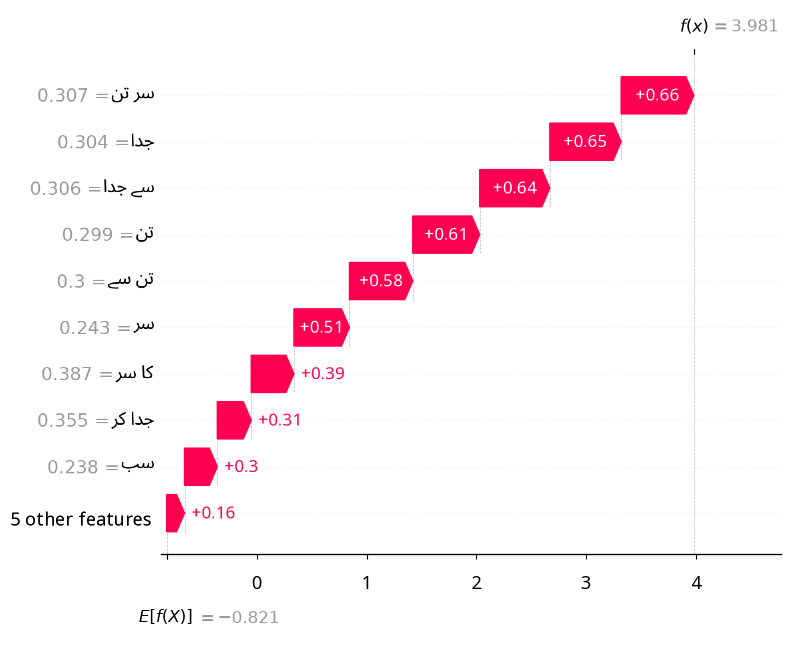


PLOT 2: BAR PLOT - Feature Importance


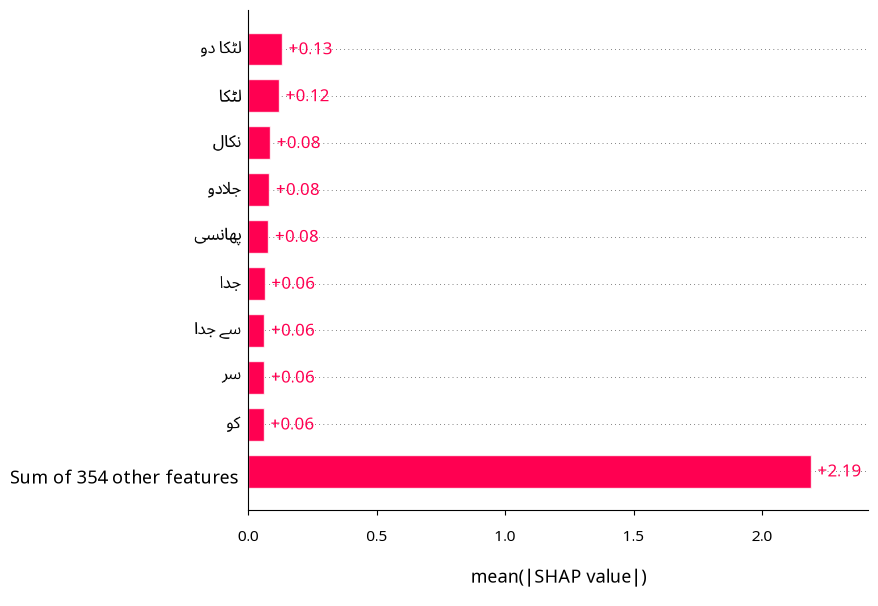


PLOT 3: BEESWARM - Feature Impact Distribution


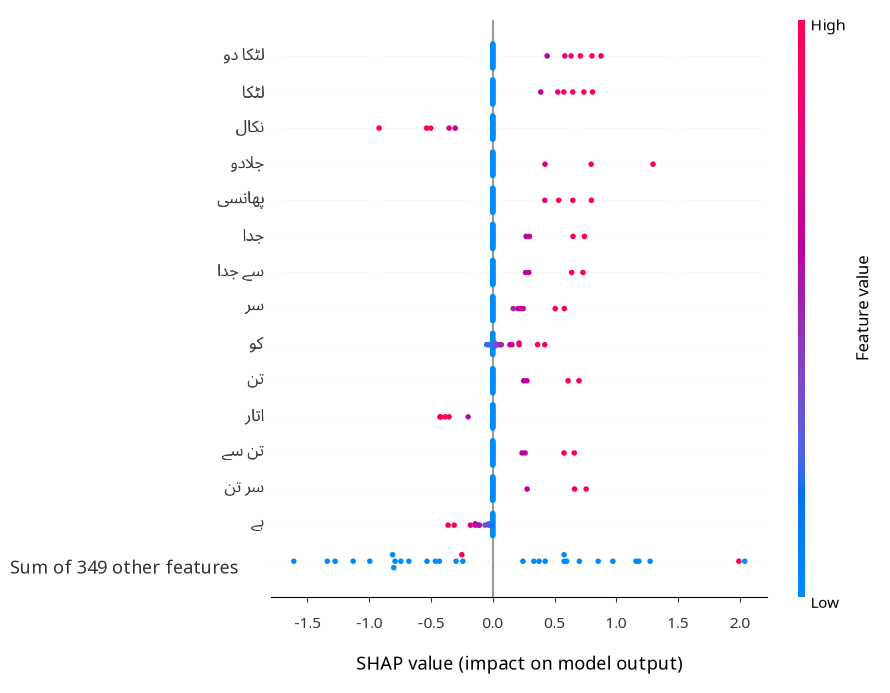


PLOT 4: SUMMARY PLOT - Feature Summary


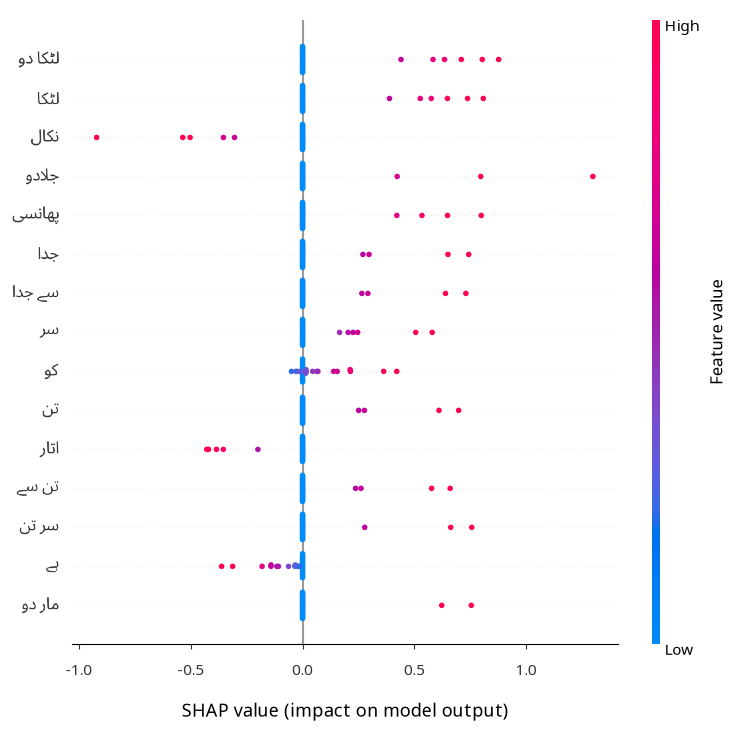


PLOT 5: HEATMAP - Sample Feature Heatmap


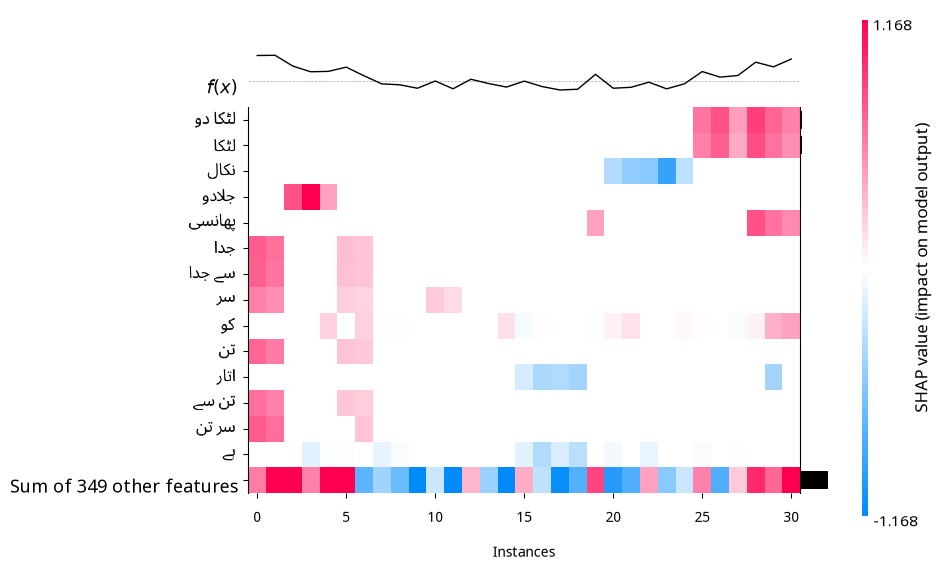


PLOT 6: SCATTER PLOT - Feature Scatter


<Figure size 1200x800 with 0 Axes>

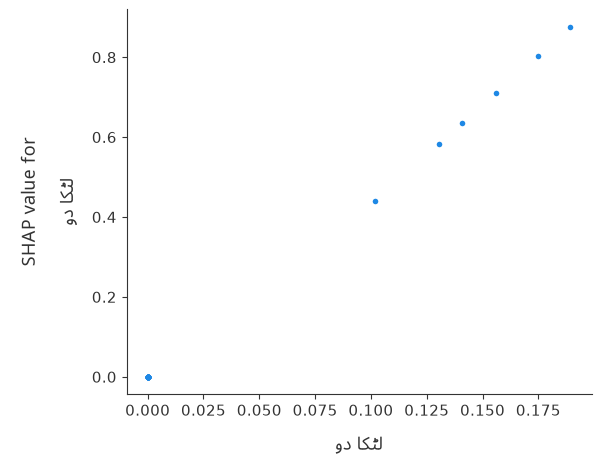


PLOT 7: DECISION PLOT - Prediction Decision Path


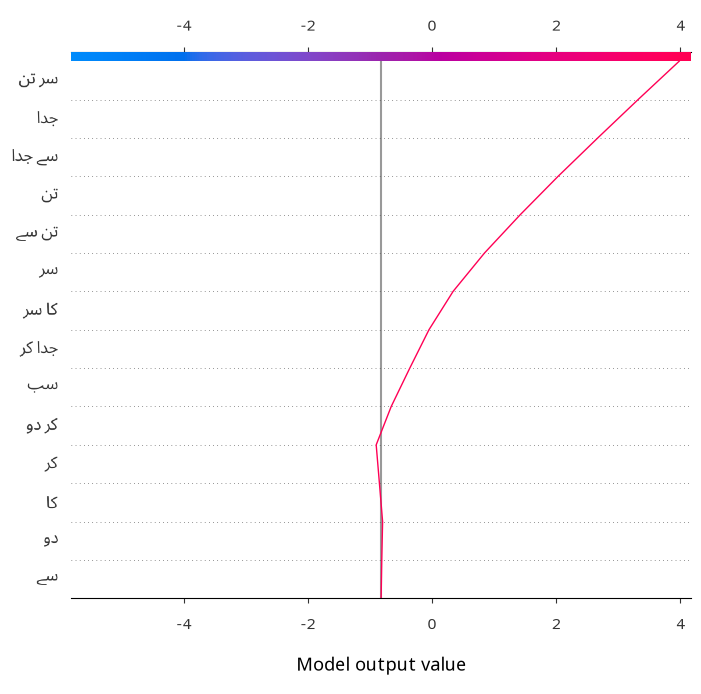


PLOT 8: DEPENDENCE PLOT - Feature Dependence


IndexError: index 31 is out of bounds for axis 0 with size 31

<Figure size 1200x800 with 0 Axes>

In [4]:

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print("=" * 80)
print("RTL SHAP PLOTS - COMPLETE DEMONSTRATION")
print("=" * 80)

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"\n✅ Model trained: {X.shape[1]} features, {len(texts)} samples")

# ============================================================
# PREPARE SAMPLES
# ============================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
print(f"\n📝 Test Tweet: {user_tweet}")

# Get random samples
n_samples = 30
random_indices = np.random.choice(len(df), n_samples, replace=False)
sample_texts = [texts[i] for i in random_indices]
sample_texts.append(user_tweet)

all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all samples
all_explanations = []
for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# Combine all explanations
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\n✅ Combined explanation shape: {combined_explanation.values.shape}")

# Get single sample for waterfall and decision plots
user_instance = vectorizer.transform([user_tweet]).toarray()[0]
user_present_idx = np.where(user_instance > 0)[0]
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
user_shap_vals = explainer(user_instance.reshape(1, -1))

user_explanation = shap.Explanation(
    values=user_shap_vals.values[0][user_present_idx],
    base_values=user_shap_vals.base_values[0],
    data=user_instance[user_present_idx],
    feature_names=[all_feature_names[i] for i in user_present_idx]
)

print(f"✅ User explanation shape: {user_explanation.values.shape}")
print(f"✅ Base value: {user_explanation.base_values:.4f}")

# ============================================================
# PLOT 1: WATERFALL PLOT (Single Sample)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 1: WATERFALL - Single Sample Feature Contributions")
print("=" * 80)

plt.figure(figsize=(12, 8))
waterfall(
    shap_values=user_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 2: BAR PLOT (Feature Importance)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 2: BAR PLOT - Feature Importance")
print("=" * 80)

plt.figure(figsize=(12, 8))
bar(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 3: BEESWARM PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 3: BEESWARM - Feature Impact Distribution")
print("=" * 80)

plt.figure(figsize=(14, 10))
beeswarm(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 4: SUMMARY PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 4: SUMMARY PLOT - Feature Summary")
print("=" * 80)

plt.figure(figsize=(14, 10))
summary_plot(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 5: HEATMAP (Multiple Samples)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 5: HEATMAP - Sample Feature Heatmap")
print("=" * 80)

# Heatmap needs at least 2 samples (use combined_explanation which has multiple)
plt.figure(figsize=(14, 10))
heatmap(
    shap_values=combined_explanation,
    max_display=15,
    show=True,
    instance_order=None  # Avoid hclust error
)
plt.show()

# ============================================================
# PLOT 6: SCATTER PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 6: SCATTER PLOT - Feature Scatter")
print("=" * 80)

plt.figure(figsize=(12, 8))
scatter(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 7: DECISION PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 7: DECISION PLOT - Prediction Decision Path")
print("=" * 80)

# Decision plot needs: shap_values (2D), base_value, feature_names
plt.figure(figsize=(12, 8))
decision_plot(
    base_value=user_explanation.base_values,             # Required: base value
    shap_values=user_explanation.values.reshape(1, -1),  # 2D array (1 sample x n_features)
    feature_names=user_explanation.feature_names,
    show=True
)
plt.show()

# ============================================================
# PLOT 8: DEPENDENCE PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 8: DEPENDENCE PLOT - Feature Dependence")
print("=" * 80)

# For dependence plot, we need the original feature values
X_subset = X[:min(100, X.shape[0])]

plt.figure(figsize=(12, 8))
dependence_plot(
    shap_values=combined_explanation,
    features=X_subset,
    show=True
)
plt.show()

# ============================================================
# PLOT 9: INTERACTIVE EXPLAINER (Full Workflow)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 9: INTERACTIVE EXPLAINER - Full Workflow")
print("=" * 80)

# Create explainer - user can choose which plot they want
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# User can pass ANY plot function directly!
# No wrappers needed - just pass the function
print("\n📌 Users can call any plot like this:")
print("   urdu_explainer.run_full_analysis(")
print("       shap_values=combined_explanation,")
print("       prediction_label='تشدد',")
print("       plot_fn=summary_plot,  # ← Any plot function")
print("       sample_text=user_tweet")
print("   )")

# Example with summary plot
urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label="تشدد",
    plot_fn=summary_plot,  # ← Direct function, NO wrapper!
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n" + "=" * 80)
print("✅ ALL PLOTS COMPLETE!")
print("=" * 80)

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

Model trained with 1000 features


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

Combined explanation shape: (51, 551)
Number of features: 551

DEPENDENCE PLOT - CORRECT USAGE

📌 Feature: 'آئی'
   Index in original X: 0

Full explanation shape: (51, 1000)
Total features in full explanation: 1000
❌ Error with 'ind' parameter: shap.plots._scatter.dependence_legacy() got multiple values for keyword argument 'ind'


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

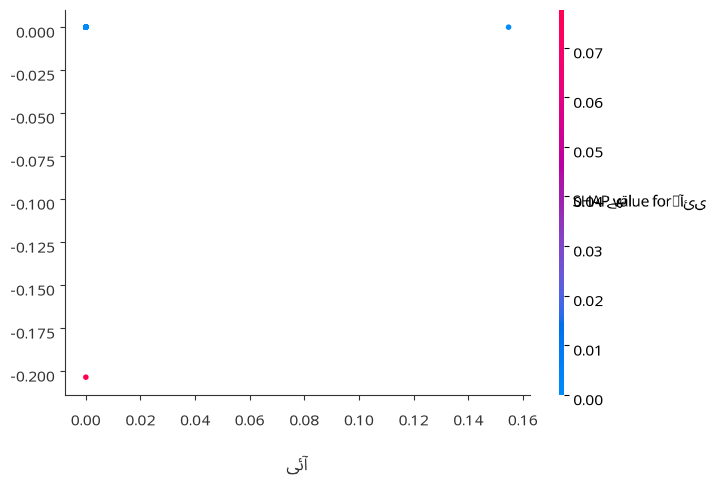

✅ Dependence plot with 'feature_index' parameter successful!

DEPENDENCE PLOT TEST COMPLETE


In [8]:
"""
Working RTL Dependence Plot
============================
This demonstrates how to properly use the dependence plot with shap_rtl.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from shap_rtl.plots import dependence_plot

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# ============================================================
# PREPARE SAMPLES
# ============================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

# Get random samples
n_samples = 50
random_indices = np.random.choice(len(df), n_samples, replace=False)
sample_texts = [texts[i] for i in random_indices]
sample_texts.append(user_tweet)

all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all samples
all_explanations = []
for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# Combine all explanations
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"Combined explanation shape: {combined_explanation.values.shape}")
print(f"Number of features: {len(all_features)}")

# ============================================================
# DEPENDENCE PLOT - CORRECT WAY
# ============================================================
print("\n" + "=" * 80)
print("DEPENDENCE PLOT - CORRECT USAGE")
print("=" * 80)

# Find a feature that exists in both X and combined_explanation
# We need to use the index from the original X
if len(all_features) > 0:
    # Get the first feature from combined explanation
    feature_name = all_features[0]
    print(f"\n📌 Feature: '{feature_name}'")
    
    # Find its index in the original vectorizer
    if feature_name in vectorizer.get_feature_names_out():
        feature_idx = list(vectorizer.get_feature_names_out()).index(feature_name)
        print(f"   Index in original X: {feature_idx}")
        
        # Use the original X with the correct number of samples
        X_subset = X[:combined_explanation.values.shape[0]]
        
        # Create a proper shap_values array with all features aligned
        # For dependence plot, we need shap_values with the same shape as X_subset
        # We need to create a full shap_values matrix with zeros for missing features
        
        shap_values_full = np.zeros((X_subset.shape[0], X_subset.shape[1]))
        
        # Fill in the values for features that exist in combined_explanation
        for i, feat in enumerate(all_features):
            if feat in vectorizer.get_feature_names_out():
                col_idx = list(vectorizer.get_feature_names_out()).index(feat)
                if col_idx < shap_values_full.shape[1]:
                    shap_values_full[:, col_idx] = combined_explanation.values[:, i]
        
        # Create a full Explanation object
        full_explanation = shap.Explanation(
            values=shap_values_full,
            base_values=combined_explanation.base_values,
            data=X_subset,
            feature_names=all_feature_names
        )
        
        print(f"\nFull explanation shape: {full_explanation.values.shape}")
        print(f"Total features in full explanation: {len(full_explanation.feature_names)}")
        
        # Plot dependence plot with the correct parameters
        plt.figure(figsize=(14, 10))
        
        try:
            # Method 1: Using 'ind' parameter (for older SHAP)
            dependence_plot(
                ind=feature_idx,
                shap_values=full_explanation.values,
                features=X_subset,
                feature_names=all_feature_names,
                show=True
            )
            plt.show()
            print("✅ Dependence plot with 'ind' parameter successful!")
        except Exception as e:
            print(f"❌ Error with 'ind' parameter: {e}")
            
            # Method 2: Using 'feature_index' parameter (for newer SHAP)
            try:
                plt.figure(figsize=(14, 10))
                dependence_plot(
                    feature_index=feature_idx,
                    shap_values=full_explanation,
                    features=X_subset,
                    show=True
                )
                plt.show()
                print("✅ Dependence plot with 'feature_index' parameter successful!")
            except Exception as e2:
                print(f"❌ Error with 'feature_index' parameter: {e2}")
                
                # Method 3: Using original shap plot (fallback)
                try:
                    plt.figure(figsize=(14, 10))
                    shap.dependence_plot(
                        feature_idx,
                        shap_values_full,
                        X_subset,
                        feature_names=all_feature_names,
                        show=False
                    )
                    plt.title(f"SHAP Dependence Plot: {feature_name}")
                    plt.show()
                    print("✅ Dependence plot with original shap successful!")
                except Exception as e3:
                    print(f"❌ Error with original shap: {e3}")
                    print("Trying method 4...")
                    
                    # Method 4: Use a simpler approach with shap_values and features
                    try:
                        plt.figure(figsize=(14, 10))
                        shap.dependence_plot(
                            feature_idx,
                            full_explanation.values,
                            X_subset,
                            feature_names=all_feature_names,
                            show=False
                        )
                        plt.title(f"SHAP Dependence Plot: {feature_name}")
                        plt.show()
                        print("✅ Dependence plot with simplified approach successful!")
                    except Exception as e4:
                        print(f"❌ Error: {e4}")

print("\n" + "=" * 80)
print("DEPENDENCE PLOT TEST COMPLETE")
print("=" * 80)

Total samples: 3297


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 500 features

Sample Urdu feature names: ['آئی', 'آئے', 'آج', 'آپ', 'آپ کو']
SHAP values shape: (100, 500)
SHAP Explanation object created with shape: (100, 500)

Top 10 Features (Urdu):
  1. لٹکا: 0.2307
  2. لٹکا دو: 0.1800
  3. نکال: 0.1604
  4. میں: 0.1533
  5. کو: 0.1477
  6. پھانسی: 0.1473
  7. مار دو: 0.1460
  8. توڑ: 0.1194
  9. اتار: 0.1028
  10. اس: 0.0869

METHOD 1: Direct RTL Dependence Plot

📌 Using feature: 'لٹکا' (index: 254)
   Number of samples: 100


<Figure size 1400x1000 with 0 Axes>

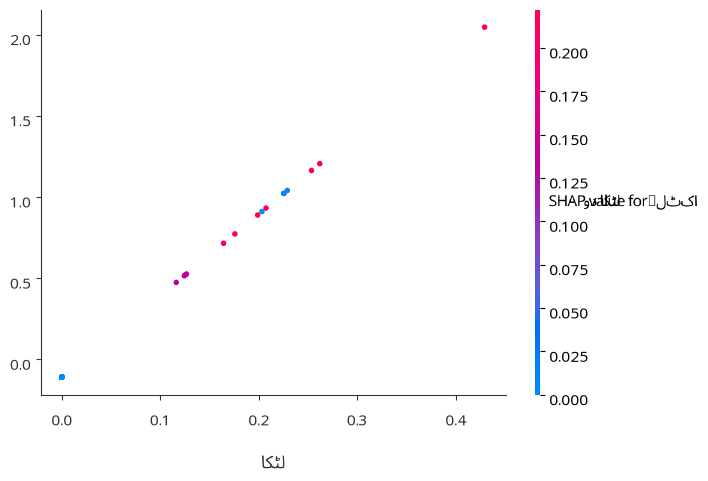

✅ RTL dependence plot successful!

METHOD 2: Using RTLSHAPExplainer

Sample text: رنگ بازی بند کرو یورپی یونین کو منہ توڑ جواب دو ۔...
Prediction label: غیر تشدد

                             URDU SHAP EXPLANATIONS                             
                              Prediction: غیر تشدد                              

[GENERATING URDU SHAP PLOT...]


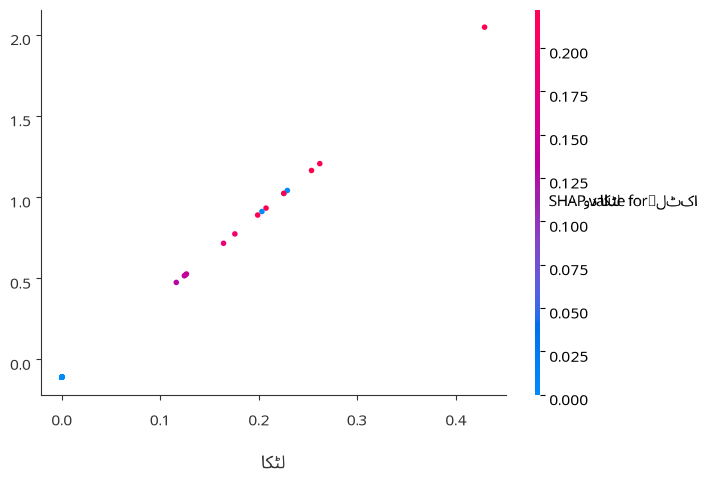

------------------------------------------------------------------------------------------------------------------------
                                                                                                 FEATURE ANALYSIS (Urdu)
------------------------------------------------------------------------------------------------------------------------
                                                                                    
Features driving TOWARD 'غیر تشدد':
                                                                                                        ﻟﭩﮑﺎ ﺩﻭ: +0.0569
                                                                                                           ﻟﭩﮑﺎ: +0.0443
                                                                                                         ﭘﮭﺎﻧﺴﯽ: +0.0379
                                                                                                          ﺟﻼ ﺩﻭ: +0.0354
                                

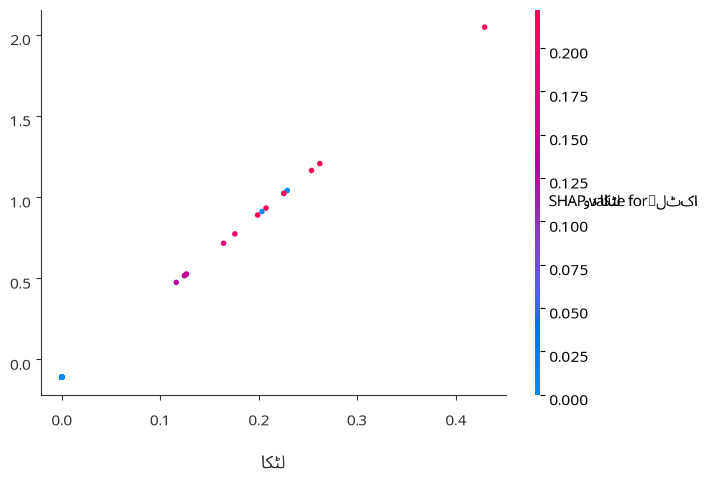


                              ENGLISH EXPLANATIONS                              

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Urdu Text:
  ﺭﻧﮓ ﺑﺎﺯﯼ ﺑﻨﺪ ﮐﺮﻭ ﯾﻮﺭﭘﯽ ﯾﻮﻧﯿﻦ ﮐﻮ ﻣﻨﮧ ﺗﻮﮌ ﺟﻮﺍﺏ ﺩﻭ ۔

English Translation:
  Stop playing with colors, give a befitting response to the European Union.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                            PREDICTION: Non-violence                            
--------------------------------------------------------------------------------

Translated Sample: Stop playing with colors, give a befitting response to the European Union.
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: criminal | Value: +0.0443
----------------------------------------
The Ur

In [3]:
"""
Working RTL Dependence Plot with Urdu Feature Names - FIXED
============================================================
Uses shap_rtl.plots.dependence_plot for RTL rendering.
Passes proper SHAP Explanation object to the explainer.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Import your RTL library
from shap_rtl.plots import dependence_plot
from shap_rtl import RTLSHAPExplainer

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# ============================================================
# CREATE URDU FEATURE NAMES
# ============================================================
# Get feature names from vectorizer (they are already Urdu words!)
urdu_feature_names = list(vectorizer.get_feature_names_out())

print(f"\nSample Urdu feature names: {urdu_feature_names[:5]}")

# ============================================================
# COMPUTE SHAP VALUES
# ============================================================
n_samples = 100
random_indices = np.random.choice(len(df), n_samples, replace=False)

masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

X_subset = X[random_indices]
shap_values = explainer.shap_values(X_subset)

# Get class 1 values
if isinstance(shap_values, list):
    shap_values_class = shap_values[1]
    base_value = explainer.expected_value[1] if isinstance(
        explainer.expected_value, list
    ) else explainer.expected_value
else:
    shap_values_class = shap_values
    base_value = explainer.expected_value

print(f"SHAP values shape: {shap_values_class.shape}")

# ============================================================
# CREATE SHAP EXPLANATION OBJECT (REQUIRED FOR EXPLAINER)
# ============================================================
# This is the key fix: Create a proper SHAP Explanation object
shap_exp = shap.Explanation(
    values=shap_values_class,
    base_values=base_value,
    data=X_subset,
    feature_names=urdu_feature_names
)

print(f"SHAP Explanation object created with shape: {shap_exp.values.shape}")

# ============================================================
# FIND TOP FEATURES
# ============================================================
mean_abs = np.abs(shap_values_class).mean(axis=0)
top_indices = np.argsort(mean_abs)[::-1][:10]

print("\nTop 10 Features (Urdu):")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {urdu_feature_names[idx]}: {mean_abs[idx]:.4f}")

# ============================================================
# METHOD 1: Direct Dependence Plot (RTL Library)
# ============================================================
print("\n" + "=" * 80)
print("METHOD 1: Direct RTL Dependence Plot")
print("=" * 80)

# Choose the most important feature
feature_idx = top_indices[0]
feature_name_urdu = urdu_feature_names[feature_idx]

print(f"\n📌 Using feature: '{feature_name_urdu}' (index: {feature_idx})")
print(f"   Number of samples: {shap_exp.values.shape[0]}")

plt.figure(figsize=(14, 10))

# Use your RTL library directly (NO wrapper needed)
try:
    dependence_plot(
        shap_values=shap_exp,  # Pass the Explanation object
        features=X_subset,
        feature_index=feature_idx,
        feature_names=urdu_feature_names,
        show=True
    )
    plt.show()
    print("✅ RTL dependence plot successful!")
    
except Exception as e:
    print(f"❌ Error: {e}")
    print("Trying with original SHAP as fallback...")
    
    import shap as _shap
    _shap.dependence_plot(
        feature_idx,
        shap_exp.values,
        X_subset,
        feature_names=urdu_feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feature_name_urdu}")
    plt.show()
    print("✅ Fallback plot successful!")

# ============================================================
# METHOD 2: Using RTLSHAPExplainer (with Explanation Object)
# ============================================================
print("\n" + "=" * 80)
print("METHOD 2: Using RTLSHAPExplainer")
print("=" * 80)

# Create explainer with Urdu language
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# Define a wrapper for dependence plot (NO extra parameters)
def dependence_wrapper(shap_values):
    """Wrapper to call your RTL dependence plot."""
    return dependence_plot(
        shap_values=shap_values,  # Pass the Explanation object
        features=X_subset,
        feature_index=feature_idx,
        feature_names=urdu_feature_names,
        show=True
    )

# Get a sample text for context
sample_idx = random_indices[0]
sample_text = texts.iloc[sample_idx]
prediction_label = "تشدد" if labels.iloc[sample_idx] == 1 else "غیر تشدد"

print(f"\nSample text: {sample_text[:100]}...")
print(f"Prediction label: {prediction_label}")

# Run the full analysis with dependence plot
# Pass the SHAP Explanation object (NOT the numpy array)
urdu_explainer.run_full_analysis(
    shap_values=shap_exp,  # ← Pass Explanation object here
    prediction_label=prediction_label,
    plot_fn=dependence_wrapper,
    sample_text=sample_text,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n" + "=" * 80)
print("DEPENDENCE PLOT TEST COMPLETE")
print("=" * 80)

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.



Sample: میرا فون صرف چھ ہفتے پرانا تھا جب پاکستان گئی اور جاتے ہی چوری ہو گیا ۔ واپس آ کر انشورینس کلیم کی ۔...
Label: غیر تشدد

                             URDU SHAP EXPLANATIONS                             
                              Prediction: غیر تشدد                              

[GENERATING URDU SHAP PLOT...]


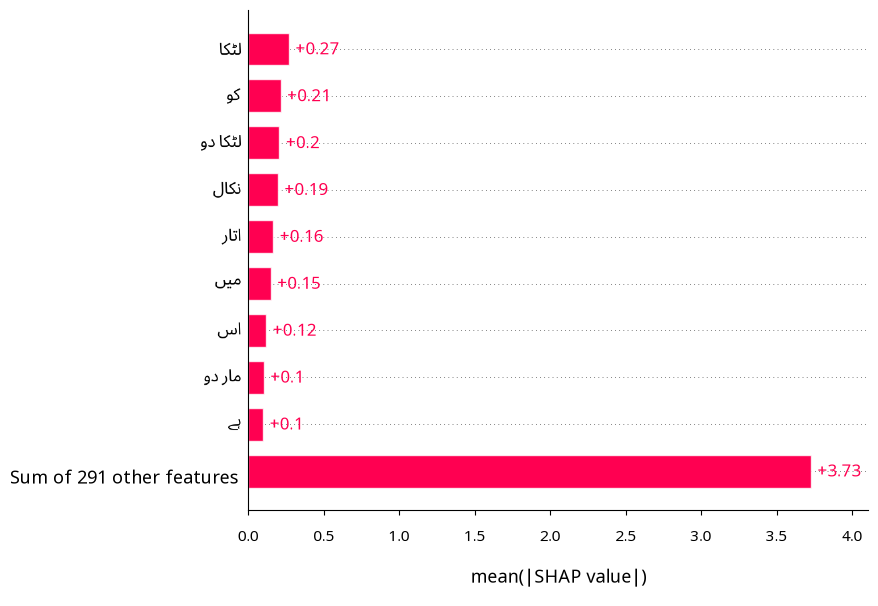


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: غیر تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻟﭩﮑﺎ | Value: +0.0123
----------------------------------------
ﻟﭩﮑﺎ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻏﯿﺮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﯾﺴﮯ ﻟﻔﻆ ﮨﮯ ﺟﻮ ﻋﺎﻡ ﻃﻮﺭ ﭘﺮ ﺗﺸﺪﺩ ﺳﮯ ﺩﻭﺭ ﮐﺮﻧﮯ ﻭﺍﻟﮯ ﻣﺎﺣﻮﻝ ﯾﺎ ﺻﻮﺭﺕ ﺣﺎﻝ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﺎ ﮨﮯ۔ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﺍﯾﺴﯽ ﺣﺎﻟﺘﻮﮞ ﻣﯿﮟ ﮨﻮﺗﺎ ﮨﮯ ﺟﮩﺎﮞ ﮐﻮﺋﯽ ﺷﺨﺺ ﯾﺎ ﭼﯿﺰ ﺧﻄﺮﮮ ﺳﮯ ﺑﭽﺎ ﮨﻮﺍ ﮨﻮ ﯾﺎ ﮐﺴﯽ ﻣﺸﮑﻞ ﺳﮯ ﮔﺰﺭ ﮐﺮ ﺁﺭﺍﺍﻡ ﮐﯽ ﻃﺮﻑ ﺑﮍﮪ ﺭﮨﺎ ﮨﻮ، ﺟﻮ ﮐﮧ ﻏﯿﺮ ﺗﺸﺪﺩ ﮐﯽ ﻃﺮﻑ ﺍﯾﮏ ﻣﺜﺒﺖ ﺍﺷﺎﺭﮦ ﮨﮯ۔
--------------------------------------

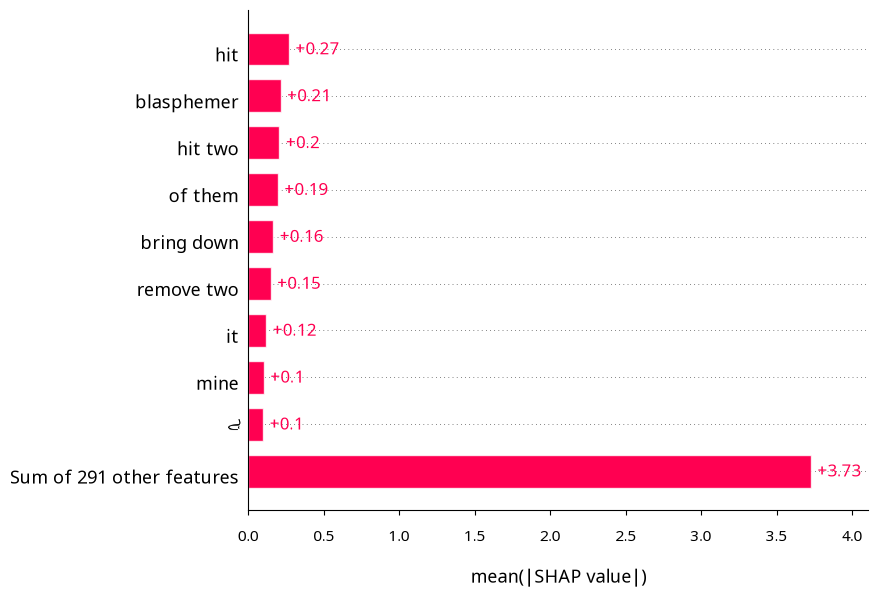


[INFO] Exiting. Thank you!

✅ Complete!


In [4]:
"""
Test Bar Plot with English Translation - Automatic
===================================================
This tests the full workflow with bar plot.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from shap_rtl.plots import bar
from shap_rtl import RTLSHAPExplainer

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# ============================================================
# COMPUTE SHAP VALUES
# ============================================================
n_samples = 50
random_indices = np.random.choice(len(df), n_samples, replace=False)

masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

X_subset = X[random_indices]
shap_values = explainer.shap_values(X_subset)

if isinstance(shap_values, list):
    shap_values_class = shap_values[1]
    base_value = explainer.expected_value[1] if isinstance(
        explainer.expected_value, list
    ) else explainer.expected_value
else:
    shap_values_class = shap_values
    base_value = explainer.expected_value

urdu_feature_names = list(vectorizer.get_feature_names_out())

shap_exp = shap.Explanation(
    values=shap_values_class,
    base_values=base_value,
    data=X_subset,
    feature_names=urdu_feature_names
)

# ============================================================
# RUN WITH EXPLAINER - ENGLISH PLOT WILL BE SHOWN
# ============================================================
sample_idx = random_indices[0]
sample_text = texts.iloc[sample_idx]
prediction_label = "تشدد" if labels.iloc[sample_idx] == 1 else "غیر تشدد"

print(f"\nSample: {sample_text[:100]}...")
print(f"Label: {prediction_label}")

# Create explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# Run with bar plot - when user says YES to English, 
# the plot will regenerate with English names
explainer_rtl.run_full_analysis(
    shap_values=shap_exp,
    prediction_label=prediction_label,
    plot_fn=bar,  # ← DIRECT function
    sample_text=sample_text,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n✅ Complete!")

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


SHAP shape: (100, 500)

Top feature: لٹکا (index: 254)

Sample: کومنٹ پڑھ کر اگر شرم ہے تو گوادر پورٹ سے چھلانگ مار دو شائد فرعون کی طرح سمندر تمھیں بھی قبول نا کرے...
Label: غیر تشدد

                             URDU SHAP EXPLANATIONS                             
                              Prediction: غیر تشدد                              

[GENERATING URDU SHAP PLOT...]


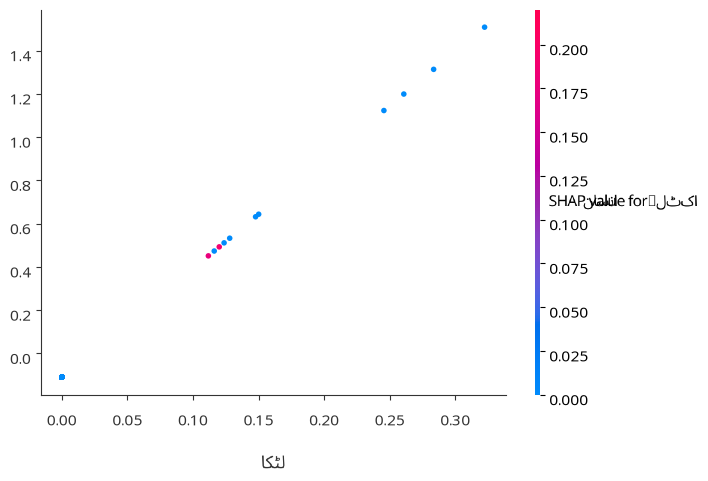


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: غیر تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻟﭩﮑﺎ | Value: -0.0087
----------------------------------------
ﻟﻔﻆ "ﻟﭩﮑﺎ" ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "ﻏﯿﺮ ﺗﺸﺪﺩ" ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﺗﺸﺪﺩ ﯾﺎ ﺟﺴﻤﺎﻧﯽ ﺯﺑﺮ ﺩﺳﺘﯽ ﮐﮯ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺧﯿﺎﻝ ﭘﯿﺪﺍ ﮨﻮﺗﺎ ﮨﮯ ﮐﮧ ﻏﯿﺮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺸﻦ ﮔﻮﺋﯽ ﮐﮯ ﺧﻼﻑ ﮨﮯ۔ ﺍﺱ ﻟﻔﻆ ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﺳﮯ ﻣﺎﮈﻝ ﮐﻮ ﯾﮧ ﺍﺷﺎﺭﮦ ﻣﻠﺘﺎ ﮨﮯ ﮐﮧ ﺗﺸﺪﺩ ﮐﯽ ﺍﻣﮑﺎﻧﺎﺕ ﺯﯾﺎﺩﮦ ﮨﯿﮟ، ﺟﺲ ﮐﯽ ﻭﺟﮧ ﺳﮯ ﻏﯿﺮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺸﻦ ﮔﻮﺋﯽ ﮐﻢ ﮨﻮ ﺟﺎﺗﯽ ﮨﮯ۔
----------------------------------------



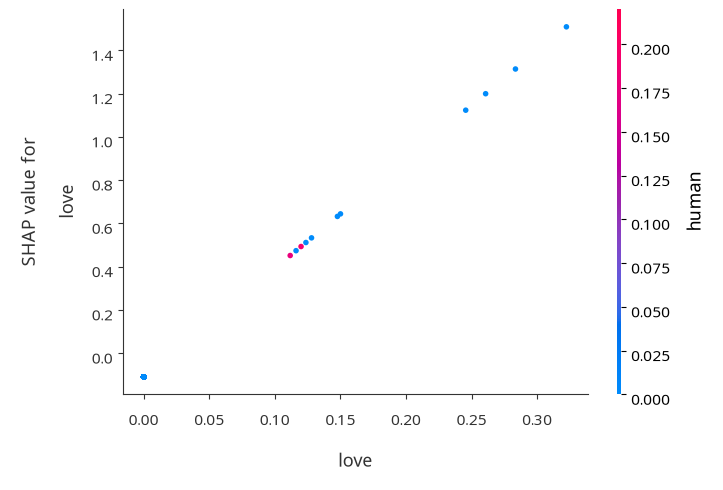


                              ENGLISH EXPLANATIONS                              

Translated Sample: If you are ashamed after reading the comment, then jump from Gwadar port, perhaps like Pharaoh, the sea will not accept you either.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                            PREDICTION: Non-violence                            
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: love | Value: -0.0087
----------------------------------------
In the context of predicting 'Non-violence', the Urdu feature 'love' (SHAP value: -0.0087) negatively impacts the model output, suggesting that the presence of 'love' in the text slightly decreases the likelihood of the model predicting 'Non-viole

In [3]:
"""
Test Dependence Plot with Simple Wrapper
=========================================
Using a simple wrapper to handle the features parameter.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from shap_rtl.plots import dependence_plot
from shap_rtl import RTLSHAPExplainer

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# ============================================================
# COMPUTE SHAP VALUES
# ============================================================
n_samples = 100
random_indices = np.random.choice(len(df), n_samples, replace=False)

masker = shap.maskers.Independent(data=X, max_samples=100)
explainer_shap = shap.LinearExplainer(model, masker=masker)

X_subset = X[random_indices]
shap_values = explainer_shap.shap_values(X_subset)

if isinstance(shap_values, list):
    shap_values_class = shap_values[1]
    base_value = explainer_shap.expected_value[1] if isinstance(
        explainer_shap.expected_value, list
    ) else explainer_shap.expected_value
else:
    shap_values_class = shap_values
    base_value = explainer_shap.expected_value

urdu_feature_names = list(vectorizer.get_feature_names_out())

shap_exp = shap.Explanation(
    values=shap_values_class,
    base_values=base_value,
    data=X_subset,
    feature_names=urdu_feature_names
)

print(f"SHAP shape: {shap_exp.values.shape}")

# ============================================================
# FIND TOP FEATURE
# ============================================================
mean_abs = np.abs(shap_values_class).mean(axis=0)
top_idx = np.argmax(mean_abs)
top_feature = urdu_feature_names[top_idx]

print(f"\nTop feature: {top_feature} (index: {top_idx})")

# ============================================================
# CREATE WRAPPER FOR DEPENDENCE PLOT
# ============================================================
def dependence_wrapper(shap_values):
    """Simple wrapper that passes features."""
    return dependence_plot(
        shap_values=shap_values,
        features=X_subset,  # Use the features from our data
        show=True
    )

# ============================================================
# RUN WITH EXPLAINER
# ============================================================
sample_idx = random_indices[0]
sample_text = texts.iloc[sample_idx]
prediction_label = "تشدد" if labels.iloc[sample_idx] == 1 else "غیر تشدد"

print(f"\nSample: {sample_text[:100]}...")
print(f"Label: {prediction_label}")

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# Use the wrapper
explainer_rtl.run_full_analysis(
    shap_values=shap_exp,
    prediction_label=prediction_label,
    plot_fn=dependence_wrapper,  # ← Wrapper function
    sample_text=sample_text,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n✅ Complete!")

Total samples: 3297
Class distribution: [2475  822]


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 300 features

📝 User Tweet: سب کافر دشمنوں کا سر تن سے جدا کر دو

✅ SHAP explanation for user tweet:
   Features present: 13
   Top features: ['تن', 'تن سے', 'جدا', 'جدا کر', 'دو']...
   Base value: -0.7207

📊 Prediction: 1 (Probability: 0.979)
🏷️ Label: تشدد

🔝 Top 10 Features for User Tweet:
  1. سر تن: +0.6852
  2. جدا: +0.6657
  3. سے جدا: +0.6517
  4. تن: +0.6234
  5. تن سے: +0.5932
  6. سر: +0.4286
  7. جدا کر: +0.3199
  8. کر دو: +0.2766
  9. سب: +0.2750
  10. کر: -0.0611

RUNNING EXPLAINER WITH USER TWEET

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


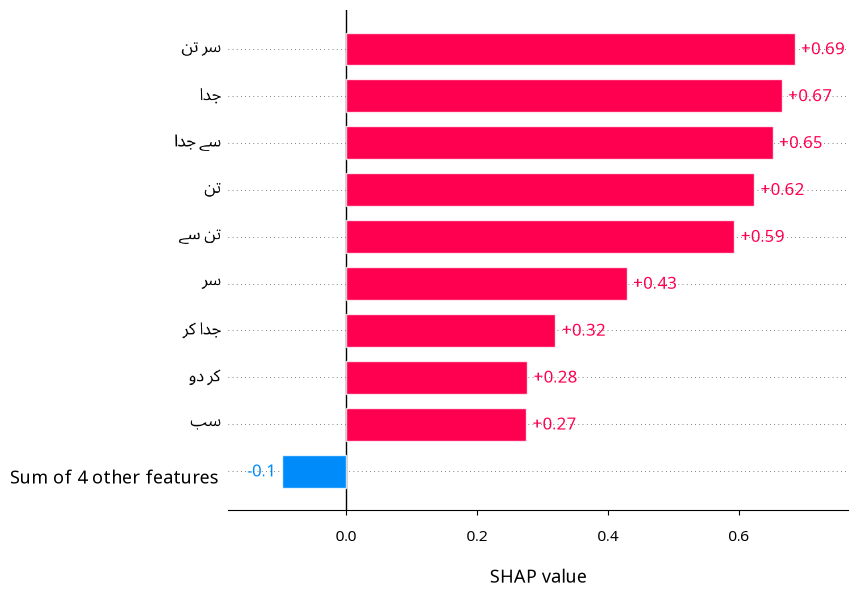


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺳﺮ ﺗﻦ | Value: +0.6852
----------------------------------------
ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻧﺴﺎﻧﯽ ﺟﺴﻢ ﮐﺎ ﺍﯾﮏ ﺣﺴﺎﺱ ﺣﺼﮧ ﮨﮯ ﺟﻮ ﺗﺸﺪﺩ ﮐﮯ ﺍﺛﺮﺍﺕ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﺎ ﮨﮯ۔ ﺍﺱ ﺣﺼﮯ ﭘﺮ ﺁﻧﮯ ﻭﺍﻟﯽ ﭼﻮﭨﯿﮟ ﯾﺎ ﺯﺧﻤﯿﮟ ﺗﺸﺪﺩ ﮐﯽ ﺷﺪﺕ ﮐﻮ ﺑﮍﮬﺎ ﺳﮑﺘﯽ ﮨﯿﮟ، ﺟﺲ ﺳﮯ ﭘﯿﺶ ﮔﻮﺋﯽ ﻣﯿﮟ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﮍﺗﺎ ﮨﮯ۔ ﺍﺱ ﻟﯿﮯ، ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﻮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻟﯿﮯ ﺍﮨﻢ ﺳﻤﺠﮭﺎ ﺟﺎﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating Englis

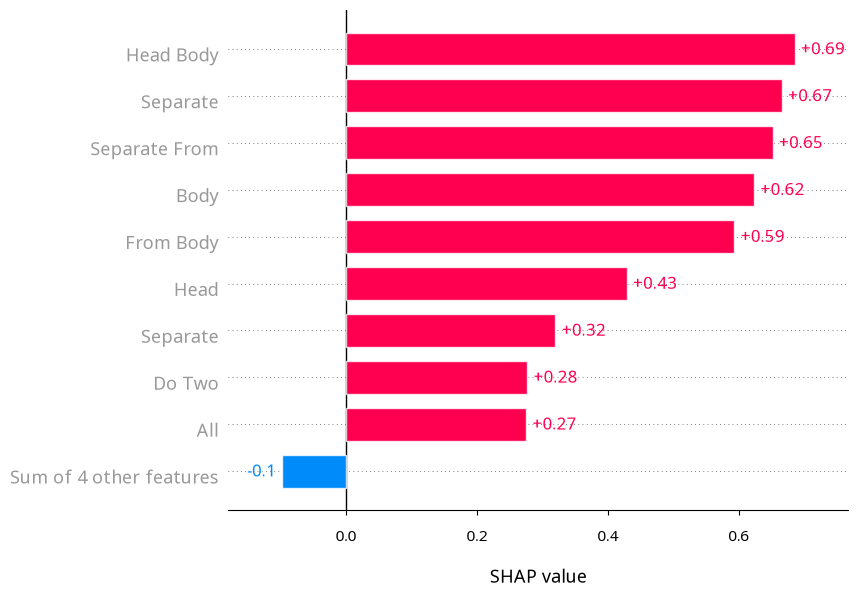


                              ENGLISH EXPLANATIONS                              

Translated Sample: Behead all infidel enemies
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Strictness                             
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Head Body | Value: +0.6852
----------------------------------------
The Urdu feature 'Head Body' has a significant positive impact on the model's prediction of 'Strictness' with a SHAP value of +0.6852, indicating that the presence of this feature increases the likelihood of a strict outcome. This is likely because the term 'Head Body' implies a sense of authority, control, and discipline, which are all closely 

In [5]:
"""
Test Bar Plot with English Translation - User Tweet
====================================================
This tests the full workflow with bar plot using a specific tweet.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from shap_rtl.plots import bar
from shap_rtl import RTLSHAPExplainer

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")
print(f"Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# ============================================================
# USER TWEET - SPECIFIC SAMPLE
# ============================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
print(f"\n📝 User Tweet: {user_tweet}")

# ============================================================
# COMPUTE SHAP VALUES FOR USER TWEET
# ============================================================
# We need to compute SHAP values for the specific tweet
# First, vectorize the tweet
user_instance = vectorizer.transform([user_tweet]).toarray()[0]
user_present_idx = np.where(user_instance > 0)[0]

# Get SHAP values for this specific instance
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
user_shap_vals = explainer(user_instance.reshape(1, -1))

# Get feature names (Urdu)
urdu_feature_names = list(vectorizer.get_feature_names_out())

# Create SHAP Explanation object for the user tweet
# Get only the features present in the tweet
user_feature_names = [urdu_feature_names[i] for i in user_present_idx]
user_shap_values = user_shap_vals.values[0][user_present_idx]
user_data = user_instance[user_present_idx]

shap_exp_user = shap.Explanation(
    values=user_shap_values,
    base_values=user_shap_vals.base_values[0],
    data=user_data,
    feature_names=user_feature_names
)

print(f"\n✅ SHAP explanation for user tweet:")
print(f"   Features present: {len(user_feature_names)}")
print(f"   Top features: {user_feature_names[:5]}...")
print(f"   Base value: {user_shap_vals.base_values[0]:.4f}")

# Get prediction for user tweet
pred = model.predict(user_instance.reshape(1, -1))[0]
pred_prob = model.predict_proba(user_instance.reshape(1, -1))[0]

print(f"\n📊 Prediction: {pred} (Probability: {pred_prob[1]:.3f})")
prediction_label = "تشدد" if pred == 1 else "غیر تشدد"
print(f"🏷️ Label: {prediction_label}")

# ============================================================
# SHOW TOP FEATURES FOR USER TWEET
# ============================================================
print("\n🔝 Top 10 Features for User Tweet:")
sorted_idx = np.argsort(np.abs(user_shap_values))[::-1][:10]
for i, idx in enumerate(sorted_idx):
    feat = user_feature_names[idx]
    val = user_shap_values[idx]
    print(f"  {i+1}. {feat}: {val:+.4f}")

# ============================================================
# RUN WITH EXPLAINER - BAR PLOT WITH USER TWEET
# ============================================================
print("\n" + "=" * 80)
print("RUNNING EXPLAINER WITH USER TWEET")
print("=" * 80)

# Create explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# Run with bar plot - when user says YES to English, 
# the plot will regenerate with English names
explainer_rtl.run_full_analysis(
    shap_values=shap_exp_user,  # ← SHAP values for the user tweet
    prediction_label=prediction_label,
    plot_fn=bar,  # ← DIRECT function
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n" + "=" * 80)
print("✅ COMPLETE!")
print("=" * 80)